# GitHub Repository Exploratory Data Analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns



## Dataset Loading

In [2]:
df = pd.read_csv(r"..\data\processed\github_repositories_cleaned.csv")
topics_df = pd.read_csv(r"..\data\processed\github_repositories_topics_final.csv")
topic_summary = pd.read_csv(r"..\data\processed\github_topic_summary.csv")
category_summary = pd.read_csv(r"..\data\processed\github_category_summary.csv")

## Dataset Overview


In [3]:
df.head()

,owner,name,description,stars,forks,watchers,repo_size,language,created_at,updated_at,...,open_issues,license,topics,has_issues,has_wiki,has_discussions,archived,default_branch,visibility,url
0,PaddlePaddle,PaddlePaddle/PaddleOCR,Turn any PDF or image document into structured...,90276,11414,90276,1970859,Python,2020-05-08 10:38:16+00:00,2026-09-27 15:15:43+00:00,...,252,Apache-2.0,"['ai4science', 'chineseocr', 'document-parsing...",True,False,True,False,main,public,https://github.com/PaddlePaddle/PaddleOCR
1,Z4nzu,Z4nzu/hackingtool,ALL IN ONE Hacking Tool For Hackers,79775,9038,79775,6457,Python,2020-04-11 09:21:31+00:00,2026-09-27 15:24:53+00:00,...,134,MIT,"['allinonehackingtool', 'besthackingtool', 'ct...",True,True,False,False,master,public,https://github.com/Z4nzu/hackingtool
2,ultralytics,ultralytics/yolov5,Ultralytics YOLOv5 in PyTorch for object detec...,58091,17461,58091,18127,Python,2020-05-18 03:45:11+00:00,2026-09-27 09:35:42+00:00,...,31,AGPL-3.0,"['computer-vision', 'coreml', 'deep-learning',...",True,True,True,False,master,public,https://github.com/ultralytics/yolov5
3,SimplifyJobs,SimplifyJobs/Summer2027-Internships,"Summer 2027 software engineering, data science...",47720,3257,47720,4380013,Python,2020-05-23 20:53:18+00:00,2026-09-27 15:31:52+00:00,...,107,Unknown,"['data-science', 'fall-2026', 'github', 'inter...",True,False,False,False,dev,public,https://github.com/SimplifyJobs/Summer2027-Int...
4,coqui-ai,coqui-ai/TTS,🐸💬 - a deep learning toolkit for Text-to-Speec...,46074,6162,46074,170196,Python,2020-05-20 15:45:28+00:00,2026-09-27 14:54:35+00:00,...,2,MPL-2.0,"['deep-learning', 'glow-tts', 'hifigan', 'melg...",True,True,True,False,dev,public,https://github.com/coqui-ai/TTS


In [4]:

df[["stars","forks",'watchers',"repo_size","open_issues"]].agg(["mean","median","min","max",'std']).rename({"mean":"Average","max":"maximum",'min':"minimum","std":"standard deviation"})


,stars,forks,watchers,repo_size,open_issues
Average,4291.415936,556.848106,4291.415936,9.128417e+04,66.729054
median,119.000000,16.000000,119.000000,5.099000e+03,3.000000
minimum,0.000000,0.000000,0.000000,0.000000e+00,0.000000
maximum,249399.000000,54862.000000,249399.000000,1.011684e+08,44443.000000
standard deviation,13239.239265,2101.970246,13239.239265,1.495646e+06,657.701037


In [5]:
earliest_year=df["created_year"].min()
print("Earliest Year:",earliest_year)
latest_year = df["created_year"].max()
print("Latest Year:", latest_year)

Earliest Year: 2020
Latest Year: 2026


## Repository Growth Analysis

In [6]:
repo_count=df.groupby("created_year")["url"].count()
print("No. of Repositories  By Year:\n",repo_count)

No. of Repositories  By Year:
 created_year
2020    738
2021    756
2022    751
2023    775
2024    775
2025    787
2026    777
Name: url, dtype: int64


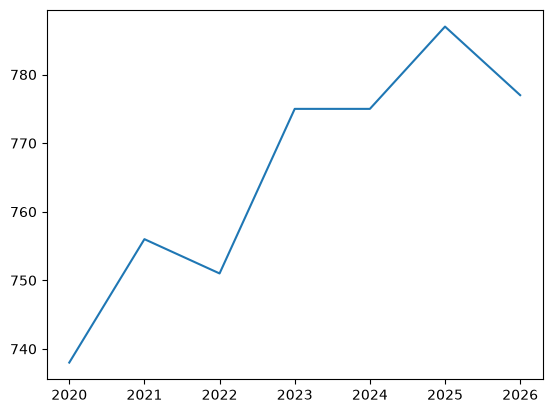

In [7]:
plt.plot(repo_count.index,repo_count.values)
plt.show()

## Repository Popularity Analysis

In [8]:
top_repos=df.sort_values(by="stars",ascending=False).head(10)


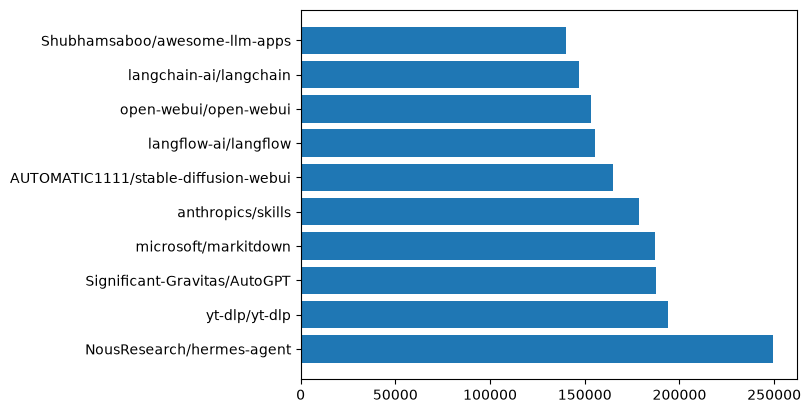

In [9]:
plt.barh(top_repos["name"],top_repos["stars"])
plt.show()

## Community Engagement Analysis

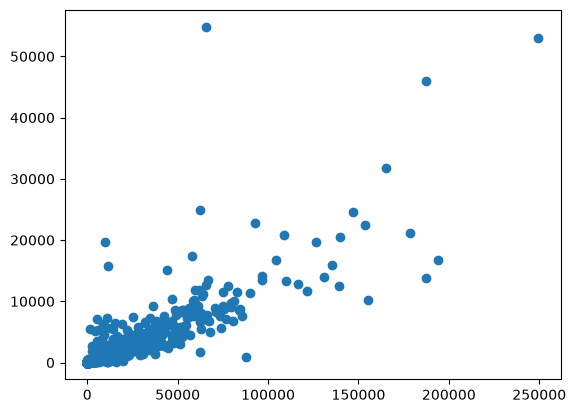

In [10]:
plt.scatter(df["stars"],df["forks"])
plt.show()

## Issue Activity Analysis


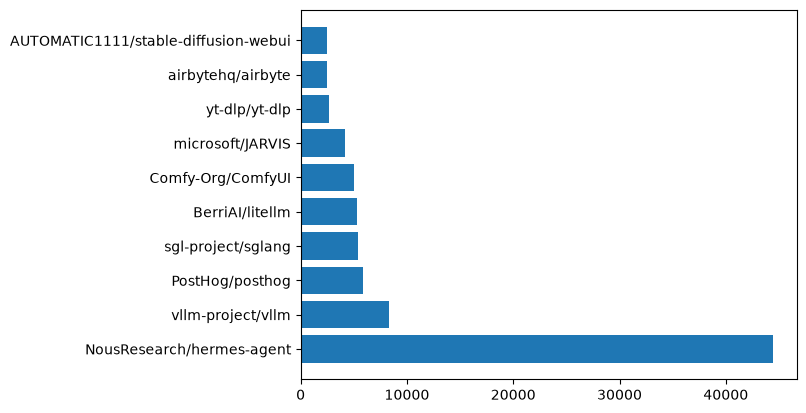

In [11]:
top_repos_by_issues=df.sort_values(by="open_issues",ascending=False).head(10)
plt.barh(top_repos_by_issues["name"],top_repos_by_issues["open_issues"])
plt.show()

## License Analysis

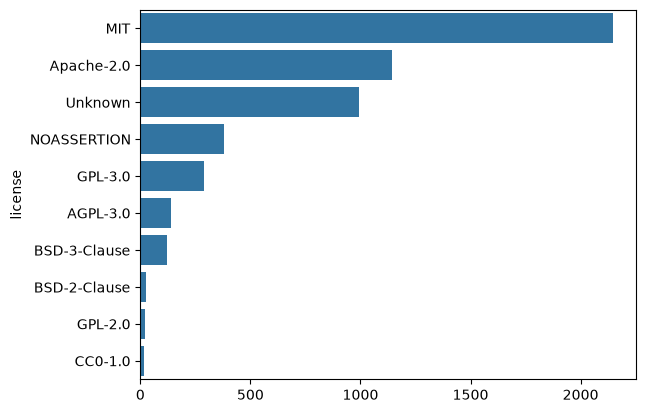

In [12]:
top_used_license=df.value_counts(subset="license",ascending=False).head(10)
sns.barplot(x=top_used_license.values,y=top_used_license.index)
plt.show()


## Development Practices Analysis

In [13]:
true_counts = df[["has_issues", "has_wiki", "has_discussions"]].sum().reset_index()
true_counts.columns=["feature","count"]
true_counts


,feature,count
0,has_issues,5279
1,has_wiki,3955
2,has_discussions,1442


In [14]:
fig=px.bar(true_counts,x="feature",y="count")
fig.show()

## Repository Activity Analysis

In [15]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])


In [16]:
df["updated_year"] = df["updated_at"].dt.year
df.head(1)


,owner,name,description,stars,forks,watchers,repo_size,language,created_at,updated_at,...,license,topics,has_issues,has_wiki,has_discussions,archived,default_branch,visibility,url,updated_year
0,PaddlePaddle,PaddlePaddle/PaddleOCR,Turn any PDF or image document into structured...,90276,11414,90276,1970859,Python,2020-05-08 10:38:16+00:00,2026-09-27 15:15:43+00:00,...,Apache-2.0,"['ai4science', 'chineseocr', 'document-parsing...",True,False,True,False,main,public,https://github.com/PaddlePaddle/PaddleOCR,2026


In [17]:
year_count=df.groupby("updated_year")['url'].count()

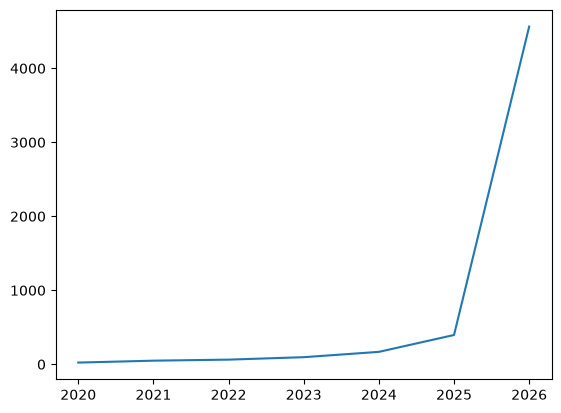

In [18]:
plt.plot(year_count.index,year_count.values)
plt.show()

## Topic Analysis

In [19]:
topic_summary.head()

,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_watchers,average_watchers,maximum_watchers,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,2317,5906440,2549.175658,25.0,193888,779652,336.492015,5906440,2549.175658,193888,80099,34.570134,50782.60121,2020,2026
1,machine-learning,AI & Machine Learning,1986,2070190,1042.391742,186.0,73526,263615,132.736657,2070190,1042.391742,73526,46589,23.458711,66540.68681,2020,2026
2,data-science,Data Science & Analytics,1416,464473,328.017655,25.0,47720,54207,38.281780,464473,328.017655,47720,17831,12.592514,61766.28249,2020,2026
3,web,Web Development,1400,263664,188.331429,4.0,165139,43678,31.198571,263664,188.331429,165139,6097,4.355000,14678.20857,2020,2026
4,artificial-intelligence,AI & Machine Learning,782,5281282,6753.557545,270.0,249399,736203,941.436061,5281282,6753.557545,249399,102681,131.305627,100506.20970,2020,2026


In [20]:
top_topics=topic_summary.sort_values(by="repository_count",ascending=False).head(10)
top_topics

,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_watchers,average_watchers,maximum_watchers,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,2317,5906440,2549.175658,25.0,193888,779652,336.492015,5906440,2549.175658,193888,80099,34.570134,50782.60121,2020,2026
1,machine-learning,AI & Machine Learning,1986,2070190,1042.391742,186.0,73526,263615,132.736657,2070190,1042.391742,73526,46589,23.458711,66540.68681,2020,2026
2,data-science,Data Science & Analytics,1416,464473,328.017655,25.0,47720,54207,38.281780,464473,328.017655,47720,17831,12.592514,61766.28249,2020,2026
3,web,Web Development,1400,263664,188.331429,4.0,165139,43678,31.198571,263664,188.331429,165139,6097,4.355000,14678.20857,2020,2026
4,artificial-intelligence,AI & Machine Learning,782,5281282,6753.557545,270.0,249399,736203,941.436061,5281282,6753.557545,249399,102681,131.305627,100506.20970,2020,2026
5,deep-learning,AI & Machine Learning,732,2042929,2790.886612,380.0,165139,287807,393.178962,2042929,2790.886612,165139,41020,56.038251,99514.85109,2020,2026
6,large-language-models,AI & Machine Learning,568,6053364,10657.330990,631.0,249399,869185,1530.255282,6053364,10657.330990,249399,119748,210.823944,82205.12852,2020,2026
7,pytorch,AI & Machine Learning,477,2059339,4317.272537,497.0,165139,310663,651.285115,2059339,4317.272537,165139,57431,120.400419,62029.74214,2020,2026
8,natural-language-processing,AI & Machine Learning,267,689494,2582.374532,185.0,75080,83730,313.595506,689494,2582.374532,75080,9705,36.348315,50113.01124,2020,2026
9,computer-vision,AI & Machine Learning,207,532180,2570.917874,351.0,62046,82197,397.086956,532180,2570.917874,62046,8391,40.536232,177932.58450,2020,2026


In [22]:
topic_summary.head()

,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_watchers,average_watchers,maximum_watchers,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,2317,5906440,2549.175658,25.0,193888,779652,336.492015,5906440,2549.175658,193888,80099,34.570134,50782.60121,2020,2026
1,machine-learning,AI & Machine Learning,1986,2070190,1042.391742,186.0,73526,263615,132.736657,2070190,1042.391742,73526,46589,23.458711,66540.68681,2020,2026
2,data-science,Data Science & Analytics,1416,464473,328.017655,25.0,47720,54207,38.281780,464473,328.017655,47720,17831,12.592514,61766.28249,2020,2026
3,web,Web Development,1400,263664,188.331429,4.0,165139,43678,31.198571,263664,188.331429,165139,6097,4.355000,14678.20857,2020,2026
4,artificial-intelligence,AI & Machine Learning,782,5281282,6753.557545,270.0,249399,736203,941.436061,5281282,6753.557545,249399,102681,131.305627,100506.20970,2020,2026


In [25]:
topic_summary["final_topic"].duplicated().sum()

np.int64(0)

In [40]:
topic_summary.shape

(13079, 17)

In [29]:
repo_count_topics=topic_summary.sort_values(by="repository_count",ascending=False).head(10)

In [34]:
fig=px.bar(repo_count_topics,x=repo_count_topics["repository_count"],y=repo_count_topics["final_topic"],orientation="h")
fig.show()

In [37]:
top_topics_stars=topic_summary.sort_values(by="total_stars",ascending=False).head(10)

<Axes: xlabel='total_stars', ylabel='final_topic'>

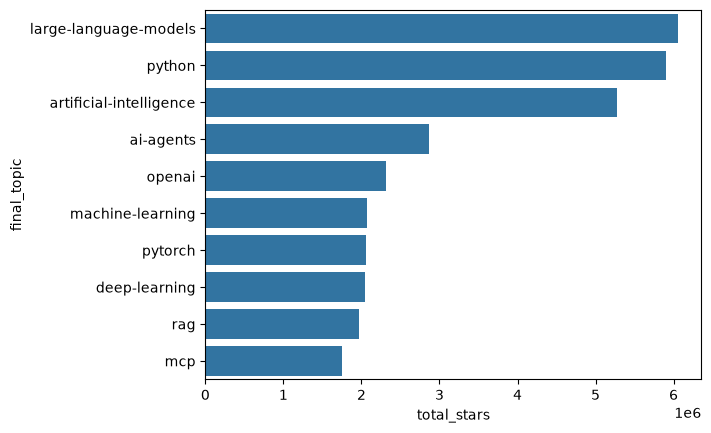

In [39]:
sns.barplot(data=top_topics_stars,x="total_stars",y="final_topic")

In [43]:
top_20_repos=topic_summary.sort_values(by="repository_count",ascending=False).head(20)

In [46]:
fig=px.treemap(data_frame=top_20_repos,path=["final_topic"],values="repository_count")
fig.show()

In [51]:
topic_summary.head()

,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_watchers,average_watchers,maximum_watchers,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,2317,5906440,2549.175658,25.0,193888,779652,336.492015,5906440,2549.175658,193888,80099,34.570134,50782.60121,2020,2026
1,machine-learning,AI & Machine Learning,1986,2070190,1042.391742,186.0,73526,263615,132.736657,2070190,1042.391742,73526,46589,23.458711,66540.68681,2020,2026
2,data-science,Data Science & Analytics,1416,464473,328.017655,25.0,47720,54207,38.281780,464473,328.017655,47720,17831,12.592514,61766.28249,2020,2026
3,web,Web Development,1400,263664,188.331429,4.0,165139,43678,31.198571,263664,188.331429,165139,6097,4.355000,14678.20857,2020,2026
4,artificial-intelligence,AI & Machine Learning,782,5281282,6753.557545,270.0,249399,736203,941.436061,5281282,6753.557545,249399,102681,131.305627,100506.20970,2020,2026


In [56]:
top_category_repo_count=topic_summary.groupby("category")["repository_count"].sum().sort_values(ascending=False).head(11).tail(10).reset_index()
top_category_repo_count

,category,repository_count
0,AI & Machine Learning,7209
1,Web Development,3072
2,Data Science & Analytics,2884
3,Python & Developer Tools,2508
4,Cybersecurity,534
5,DevOps & Cloud,498
6,Automation & Agents,410
7,Software Development,396
8,Databases,308
9,Finance & Trading,258


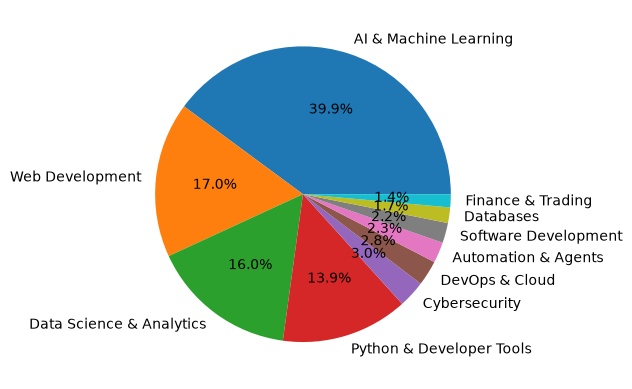

In [62]:
plt.pie(top_category_repo_count["repository_count"],labels=top_category_repo_count["category"],autopct="%1.1f%%")
plt.show()

In [77]:
top_category_stars=topic_summary.groupby('category')["total_stars"].sum().sort_values().tail(11).head(10)
top_category_stars

category
Databases                     812912
Finance & Trading            1195680
DevOps & Cloud               1201187
Cybersecurity                1633776
Software Development         1692849
Data Science & Analytics     1868514
Automation & Agents          3034810
Web Development              3959650
Python & Developer Tools     6272134
AI & Machine Learning       33155240
Name: total_stars, dtype: int64

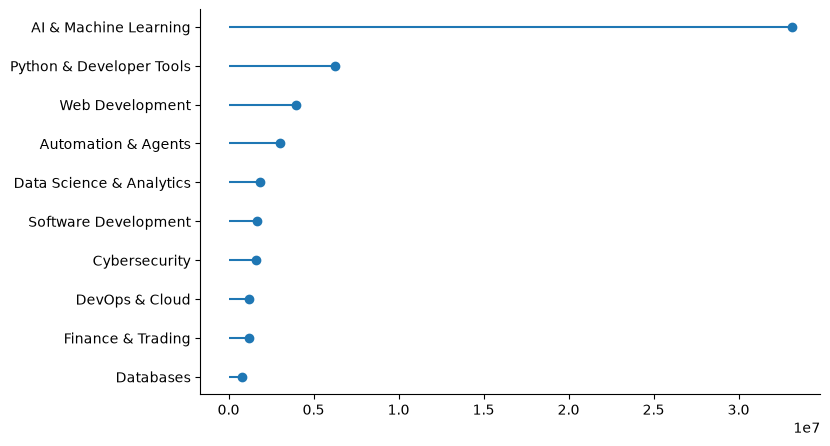

In [88]:
fig,ax=plt.subplots(figsize=(8,5))
ax.hlines(top_category_stars.index, xmin=0, xmax=top_category_stars.values)
ax.plot(top_category_stars.values,top_category_stars.index,"o")
ax.spines[["top","right"]].set_visible(False)
